## Customer Segmentation Analysis with Machine Learning
### Importing Required Libraries fo Analysis

In [100]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Clustering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA


In [101]:
# !pip install matplotlib seaborn scikit-learn

In [102]:
# !pip install -U scikit-learn

### Loading the dataset

In [103]:

df = pd.read_csv('Project1.csv')  # Replace with actual path if needed
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53.0,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14.0,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64.0,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2.0,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73.0,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23.0,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90.0,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49.0,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49.0,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31.0,PayPal,Annually


### 1. Understand and Preprocessing the Data

In [104]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53.0,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14.0,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64.0,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2.0,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73.0,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23.0,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90.0,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49.0,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49.0,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31.0,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20.0,Wyoming,M,White,Summer,2.9,Yes,Venmo,Standard,Yes,Yes,14.0,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85.0,Montana,M,Gray,Fall,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,49.0,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34.0,Louisiana,L,Charcoal,Winter,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,19.0,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97.0,West Virginia,L,Silver,Summer,2.6,Yes,Venmo,Express,Yes,Yes,8.0,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31.0,Missouri,M,Pink,Spring,4.8,Yes,PayPal,2-Day Shipping,Yes,Yes,4.0,Cash,Quarterly


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3888 non-null   float64
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3891 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

#### Data Cleaning

In [106]:
# Dropping the duplicate rows if any
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {df.duplicated().sum()} duplicate rows.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [107]:
# Checking for missing values
df.isnull().sum()

Customer ID                  0
Age                          0
Gender                       0
Item Purchased               0
Category                     0
Purchase Amount (USD)       12
Location                     0
Size                         0
Color                        0
Season                       0
Review Rating                9
Subscription Status          0
Payment Method               0
Shipping Type                0
Discount Applied             0
Promo Code Used              0
Previous Purchases           4
Preferred Payment Method     0
Frequency of Purchases       0
dtype: int64

In [108]:
#Handling the missing values (nulls) for Purchase Amount, Review Rating, Previous Purchases
# Filling the missing values using median()
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].median())
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].median())
df['Previous Purchases'] = df['Previous Purchases'].fillna(df['Previous Purchases'].median())

In [109]:
#Rechecking for the missing values after handling it
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [110]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.749231,3.749949,25.406923
std,1125.977353,15.207589,23.732300,0.715800,14.582197
min,1.000000,18.000000,0.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,100.000000


In [111]:
df[df['Purchase Amount (USD)'] == 0]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
294,295,70,Male,Skirt,Clothing,0.0,New Jersey,M,Gold,Spring,4.6,Yes,Cash,Store Pickup,Yes,Yes,19.0,Credit Card,Every 3 Months
309,310,66,Male,Dress,Clothing,0.0,Minnesota,M,Yellow,Spring,4.5,Yes,Bank Transfer,Standard,Yes,Yes,21.0,Cash,Fortnightly
394,395,43,Male,Scarf,Accessories,0.0,North Dakota,M,Beige,Spring,4.8,Yes,PayPal,Store Pickup,Yes,Yes,7.0,Debit Card,Bi-Weekly
450,451,25,Male,Boots,Footwear,0.0,Connecticut,L,Beige,Summer,2.7,Yes,Venmo,Store Pickup,Yes,Yes,19.0,Credit Card,Monthly
3884,3885,47,Female,Sandals,Footwear,0.0,Maryland,M,Brown,Fall,4.9,No,Debit Card,Express,No,No,3.0,PayPal,Weekly


In [112]:
# Removing rows where Purchase Amount = 0, since the Purchase Amount cannot be 0.
# df = df[df['Purchase Amount (USD)'] > 0]
# print("Removed rows with Purchase Amount = 0 to ensure clean clustering.")

df = df[~((df['Purchase Amount (USD)'] == 0) & 
          (df['Promo Code Used'].str.lower() == 'no') & 
          (df['Discount Applied'].str.lower() == 'no'))]

print("Removed rows with Purchase Amount = 0 only when no discount or promo was applied.")

Removed rows with Purchase Amount = 0 only when no discount or promo was applied.


#### To ensure accurate customer segmentation, used the IQR method to detect and remove outliers that could distort clustering results.


In [113]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Detect outliers in Previous Purchases
outliers_prev_purchases = detect_outliers_iqr(df, 'Previous Purchases')
print(f"Previous Purchases Outliers: {len(outliers_prev_purchases)} rows")

# Detect outliers in Review Rating
outliers_review_rating = detect_outliers_iqr(df, 'Review Rating')
print(f"Review Rating Outliers: {len(outliers_review_rating)} rows")


Previous Purchases Outliers: 3 rows
Review Rating Outliers: 0 rows


#### Boxplots helped visualize these outliers, while Review Rating was clean, Previous Purchases had 3 unusually high values that were removed for cleaner analysis.

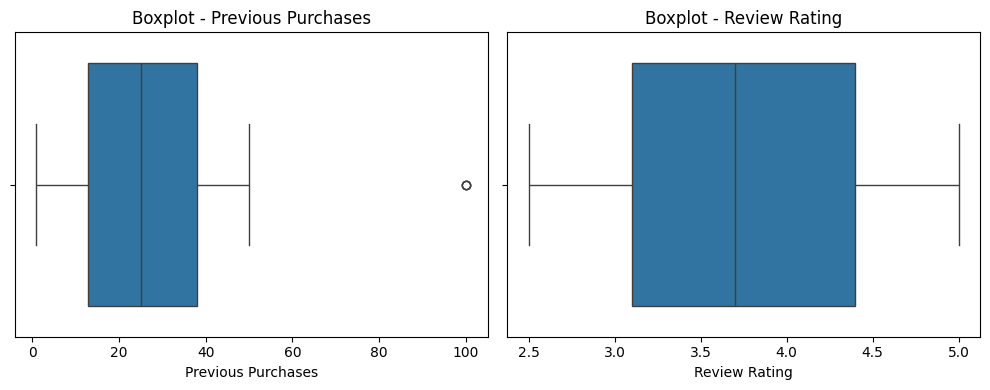

In [114]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Previous Purchases'])
plt.title('Boxplot - Previous Purchases')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Review Rating'])
plt.title('Boxplot - Review Rating')

plt.tight_layout()
plt.show()


- The box is slightly skewed right for Previous Purchases.
- The 3 outliers are visually represented as small circles to the far right — unusually high purchase counts.
- For Review Rating the data is clean, no outliers detected.

In [115]:
# Remove outliers from Previous Purchases
df = df[~df.index.isin(outliers_prev_purchases.index)]
print("Removed 3 outlier rows from Previous Purchases.")


Removed 3 outlier rows from Previous Purchases.


#### Data Cleaning Summary
- Imputed missing values in Purchase Amount (USD), Review Rating, and Previous Purchases using the median.
- Removed rows with Purchase Amount = 0 to ensure clean clustering.
- Detected 3 outliers in Previous Purchases and removed them; Review Rating had no outliers.



In [116]:
# Metadata after cleaning the data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3896 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3896 non-null   int64  
 1   Age                       3896 non-null   int64  
 2   Gender                    3896 non-null   object 
 3   Item Purchased            3896 non-null   object 
 4   Category                  3896 non-null   object 
 5   Purchase Amount (USD)     3896 non-null   float64
 6   Location                  3896 non-null   object 
 7   Size                      3896 non-null   object 
 8   Color                     3896 non-null   object 
 9   Season                    3896 non-null   object 
 10  Review Rating             3896 non-null   float64
 11  Subscription Status       3896 non-null   object 
 12  Payment Method            3896 non-null   object 
 13  Shipping Type             3896 non-null   object 
 14  Discount Appl

#### Feature Engineering

In [117]:
# Age Group
def categorize_age(age):
    if age < 30:
        return '18-29'
    elif age <= 50:
        return '30-50'
    else:
        return '51+'

df['Age Group'] = df['Age'].apply(categorize_age)

# Promo Buyer: 1 if either promo or discount applied
df['Is Promo Buyer'] = ((df['Promo Code Used'].str.lower() == 'yes') | 
                        (df['Discount Applied'].str.lower() == 'yes')).astype(int)

In [118]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Age Group,Is Promo Buyer
0,1,55,Male,Blouse,Clothing,53.0,Kentucky,L,Gray,Winter,...,Yes,Credit Card,Express,Yes,Yes,14.0,Venmo,Fortnightly,51+,1
1,2,19,Male,Sweater,Clothing,64.0,Maine,L,Maroon,Winter,...,Yes,Bank Transfer,Express,Yes,Yes,2.0,Cash,Fortnightly,18-29,1
2,3,50,Male,Jeans,Clothing,73.0,Massachusetts,S,Maroon,Spring,...,Yes,Cash,Free Shipping,Yes,Yes,23.0,Credit Card,Weekly,30-50,1
3,4,21,Male,Sandals,Footwear,90.0,Rhode Island,M,Maroon,Spring,...,Yes,PayPal,Next Day Air,Yes,Yes,49.0,PayPal,Weekly,18-29,1
4,5,45,Male,Blouse,Clothing,49.0,Oregon,M,Turquoise,Spring,...,Yes,Cash,Free Shipping,Yes,Yes,31.0,PayPal,Annually,30-50,1
5,6,46,Male,Sneakers,Footwear,20.0,Wyoming,M,White,Summer,...,Yes,Venmo,Standard,Yes,Yes,14.0,Venmo,Weekly,30-50,1
6,7,63,Male,Shirt,Clothing,85.0,Montana,M,Gray,Fall,...,Yes,Debit Card,Free Shipping,Yes,Yes,49.0,Cash,Quarterly,51+,1
7,8,27,Male,Shorts,Clothing,34.0,Louisiana,L,Charcoal,Winter,...,Yes,Debit Card,Free Shipping,Yes,Yes,19.0,Credit Card,Weekly,18-29,1
8,9,26,Male,Coat,Outerwear,97.0,West Virginia,L,Silver,Summer,...,Yes,Venmo,Express,Yes,Yes,8.0,Venmo,Annually,18-29,1
9,10,57,Male,Handbag,Accessories,31.0,Missouri,M,Pink,Spring,...,Yes,PayPal,2-Day Shipping,Yes,Yes,4.0,Cash,Quarterly,51+,1


### 2. Exploratory Data Analysis

#### (i) Number of Customers/Purchases by Age Group and Gender

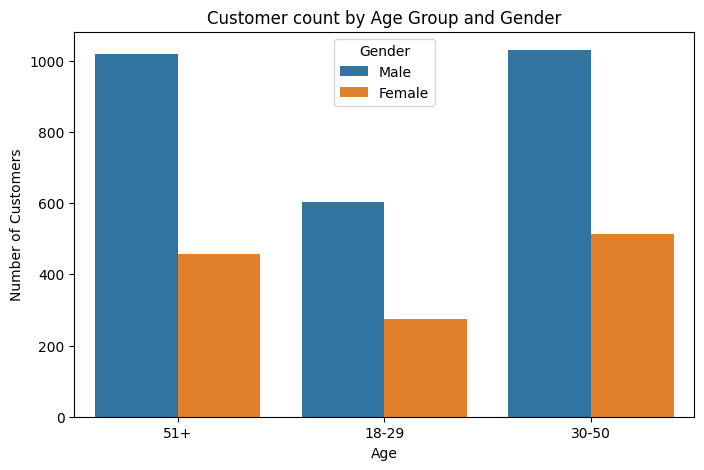

In [119]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age Group', hue='Gender')
plt.title("Customer count by Age Group and Gender")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

- Majority of customers fall into the 30–50 and 51+ age groups
- Male customers dominate across all age groups

#### (ii) Gender Wise Purchase Trend

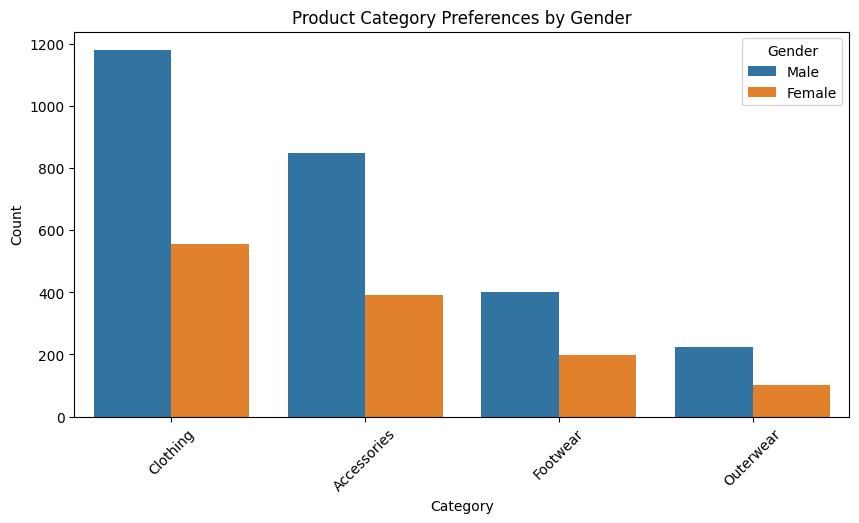

In [120]:
plt.figure(figsize=(10, 5))

# Get category counts and order them
category_order = df['Category'].value_counts().index

sns.countplot(data=df, x='Category', hue='Gender', order=category_order)
plt.title("Product Category Preferences by Gender")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.show()


- Males consistently purchase more across all product categories
- Clothing is the most popular category among both genders

#### (iii) Top 10 Locations with high purchases

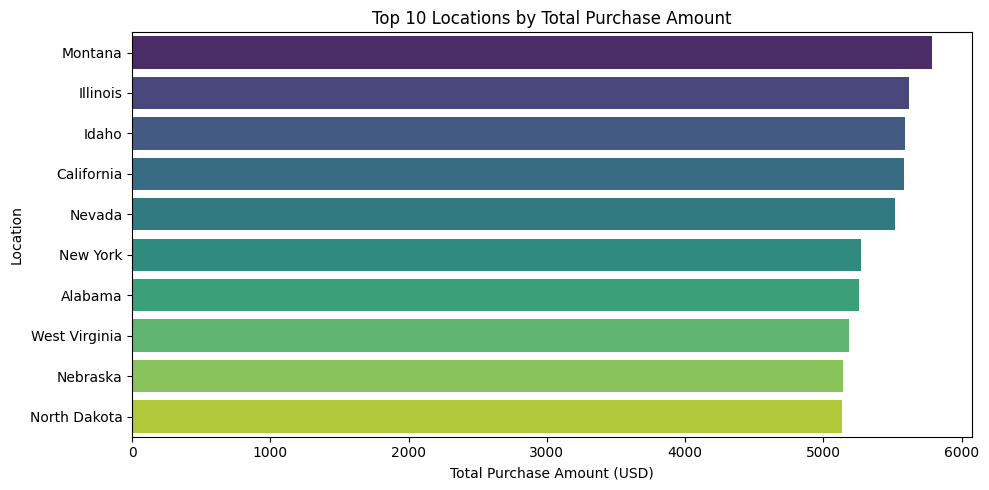

In [121]:
# Prepare top 10 locations data
top_locations = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10).reset_index()

# Plot with 'hue' set to 'Location' and legend disabled
plt.figure(figsize=(10, 5))
sns.barplot(data=top_locations, x='Purchase Amount (USD)', y='Location', hue='Location', palette='viridis', legend=False)
plt.title("Top 10 Locations by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


- Highest spending is observed in states like Montana, Illinois, and Idaho
- These regions are strong candidates for geo-targeted marketing

#### (iv) Categories with Highes Previous Purchases

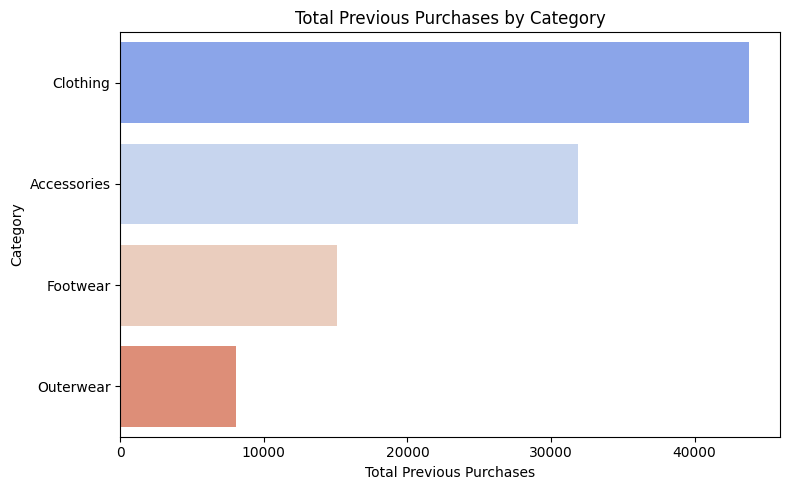

In [122]:
category_prev_purchases = df.groupby('Category')['Previous Purchases'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=category_prev_purchases, x='Previous Purchases', y='Category', hue = 'Category', palette='coolwarm', legend=False)
plt.title("Total Previous Purchases by Category")
plt.xlabel("Total Previous Purchases")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


- Clothing leads in repeat purchases, followed by accessories and footwear
- Indicates strong loyalty trends in apparel segments

#### (v) Distribution of Item Size

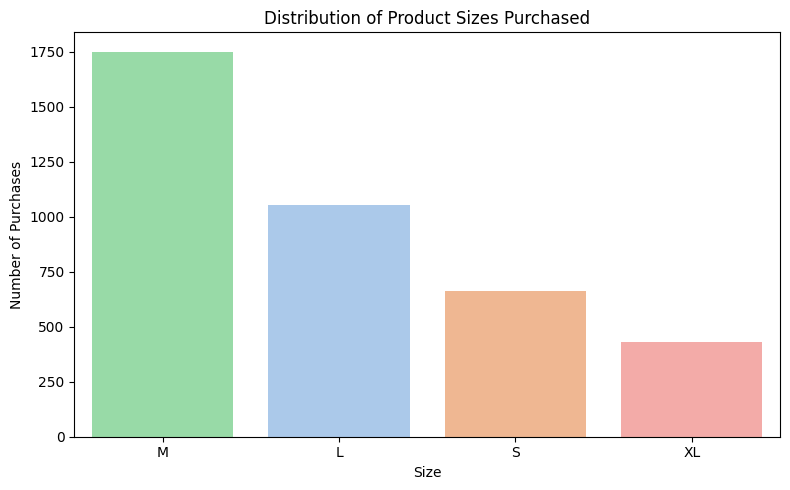

In [123]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Size', order=df['Size'].value_counts().index, hue='Size', palette='pastel',legend=False)
plt.title("Distribution of Product Sizes Purchased")
plt.xlabel("Size")
plt.ylabel("Number of Purchases")
plt.tight_layout()
plt.show()

- Most customers purchase Medium and Large sizes, which may help with inventory planning and targeted product recommendations.

#### (v) Correlation between numerical values

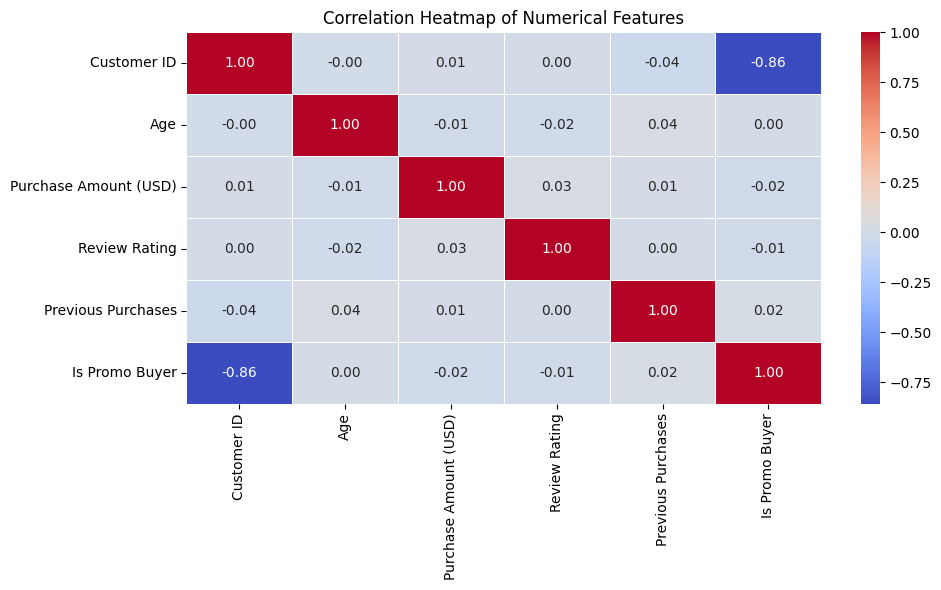

In [124]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


**The correlation heatmap shows that most numerical features are weakly correlated, indicating they contribute independently to customer behavior — ideal for clustering, while** `Customer ID` **should be excluded due to its artificial negative correlation with promo usage.**

#### (vi)  Purchases by Season

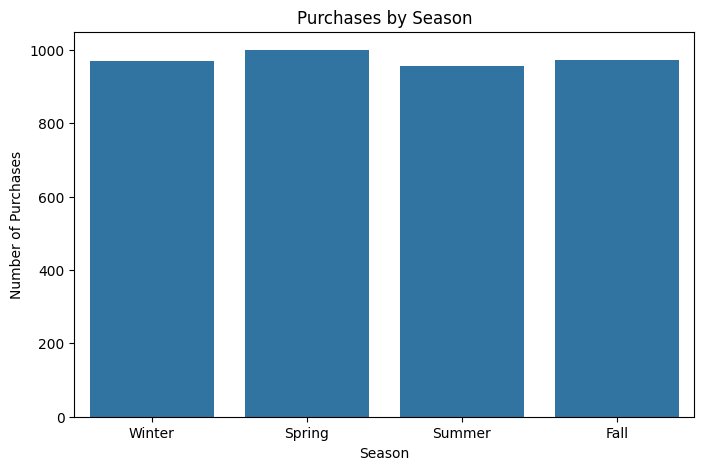

In [125]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Season')
plt.title("Purchases by Season")
plt.xlabel("Season")
plt.ylabel("Number of Purchases")
plt.show()

- Purchase volumes are evenly distributed across seasons
- No strong seasonal dependence was observed

#### (vii) Subscribers vs Non-Subscribers

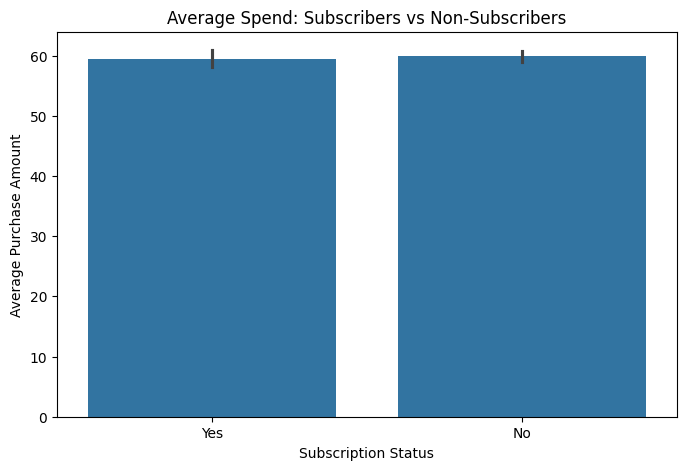

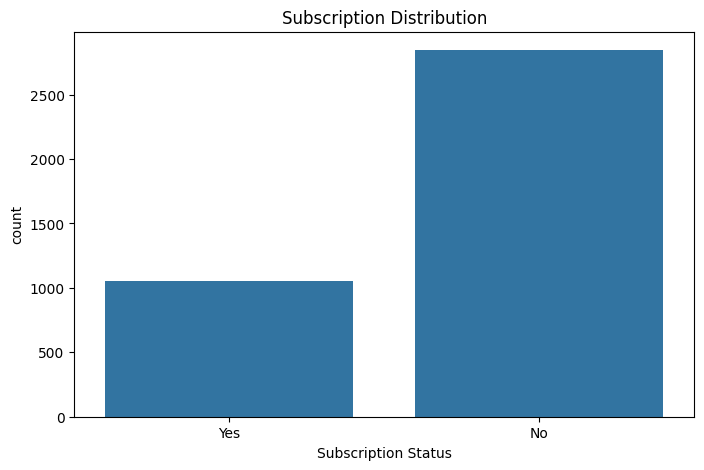

In [126]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Subscription Status', y='Purchase Amount (USD)', estimator='mean')
plt.title("Average Spend: Subscribers vs Non-Subscribers")
plt.ylabel("Average Purchase Amount")
plt.show()

# Purchase count
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Subscription Status')
plt.title("Subscription Distribution")
plt.show()


- Both groups spend similarly on average
- However, the majority of users are non-subscribers, which presents a growth opportunity for loyalty programs

### 3. Segment Customers Using Clustering

#### Encoding

In [127]:
categorical_cols = ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 
                    'Season', 'Subscription Status', 'Payment Method', 'Shipping Type', 
                    'Discount Applied', 'Promo Code Used', 'Preferred Payment Method', 
                    'Frequency of Purchases']
df_encoded = df.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

In [128]:
df_encoded.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Age Group,Is Promo Buyer
0,1,55,1,2,1,53.0,16,0,7,3,...,1,2,1,1,1,14.0,5,3,51+,1
1,2,19,1,23,1,64.0,18,0,12,3,...,1,0,1,1,1,2.0,1,3,18-29,1
2,3,50,1,11,1,73.0,20,2,12,1,...,1,1,2,1,1,23.0,2,6,30-50,1
3,4,21,1,14,2,90.0,38,1,12,1,...,1,4,3,1,1,49.0,4,6,18-29,1
4,5,45,1,2,1,49.0,36,1,21,1,...,1,1,2,1,1,31.0,4,0,30-50,1
5,6,46,1,20,2,20.0,49,1,23,2,...,1,5,4,1,1,14.0,5,6,30-50,1
6,7,63,1,16,1,85.0,25,1,7,0,...,1,3,2,1,1,49.0,1,5,51+,1
7,8,27,1,18,1,34.0,17,0,4,3,...,1,3,2,1,1,19.0,2,6,18-29,1
8,9,26,1,4,3,97.0,47,0,19,2,...,1,5,1,1,1,8.0,5,0,18-29,1
9,10,57,1,7,0,31.0,24,1,16,1,...,1,4,0,1,1,4.0,1,5,51+,1


#### Feature Selection & Standardizing

In [129]:
# Final selected features for clustering
selected_features = ['Age', 'Gender', 'Location', 'Category', 'Previous Purchases',
                     'Is Promo Buyer', 'Size', 'Purchase Amount (USD)']

# Extract features from encoded DataFrame
X = df_encoded[selected_features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### K-Means Clustering

In [130]:
# KMeans clustering with 4 clusters (you can try 3, 5, etc. too)
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


#### DBSCAN Clustering

In [131]:
# DBSCAN clustering (tweak eps/min_samples for better results if needed)
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)


#### PCA for Visualization

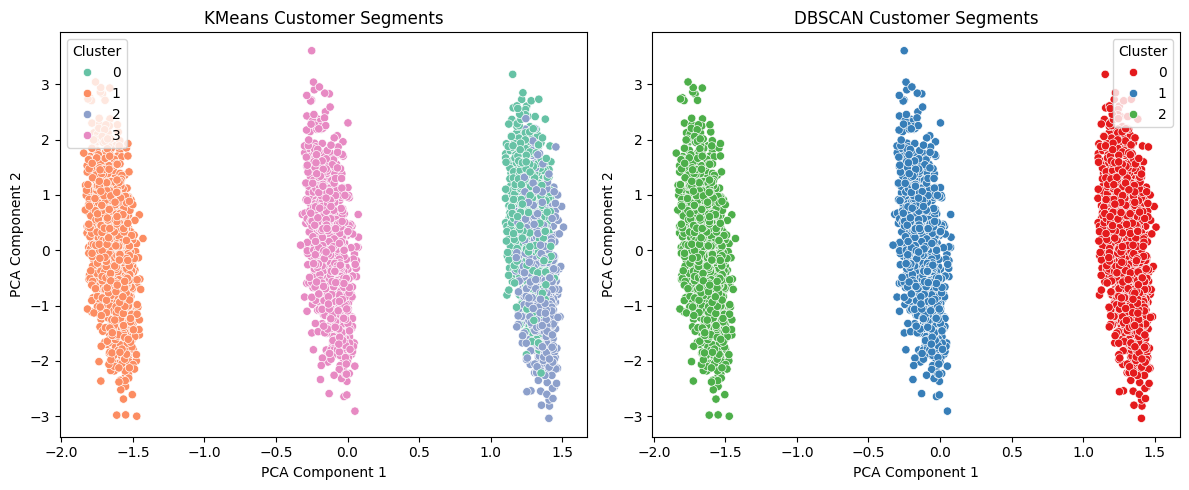

In [132]:
# Reduce dimensions for plotting
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Plot KMeans Clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=df['KMeans_Cluster'], palette='Set2')
plt.title("KMeans Customer Segments")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')

# Plot DBSCAN Clusters
plt.subplot(1, 2, 2)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                hue=df['DBSCAN_Cluster'], palette='Set1')
plt.title("DBSCAN Customer Segments")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()


### 4. Insights and Recommendations

#### Insight from K-Means Clustering

In [133]:
df['KMeans_Cluster'] = kmeans.labels_

In [134]:
cluster_summary_numeric = df.groupby('KMeans_Cluster')[['Age', 'Previous Purchases', 
                                                        'Is Promo Buyer', 'Purchase Amount (USD)']].mean()


In [135]:
# Using mode() for categorical summary
cluster_summary_categorical = df.groupby('KMeans_Cluster')[['Gender', 'Location', 'Category', 'Size']].agg(lambda x: x.mode().iloc[0])


In [136]:
cluster_summary_numeric['Count'] = df['KMeans_Cluster'].value_counts().sort_index()


In [137]:
# Combining for reporting
cluster_summary_final = pd.concat([cluster_summary_numeric, cluster_summary_categorical], axis=1)
cluster_summary_final


,Age,Previous Purchases,Is Promo Buyer,Purchase Amount (USD),Count,Gender,Location,Category,Size
KMeans_Cluster,,,,,,,,,
0,43.227326,25.275618,1.0,79.347468,849,Male,Pennsylvania,Clothing,M
1,44.012841,24.602729,0.0,60.263242,1246,Female,Montana,Clothing,M
2,45.131961,26.230024,1.0,38.657385,826,Male,Arkansas,Clothing,M
3,44.015385,25.645128,0.0,59.978462,975,Male,Vermont,Clothing,M


#### Cluster 0:
**Insight:** Mid-aged male customers who are highly promo-driven and make above-average purchases. They show strong response to discounts and promotions.
**Strategy:** Target with exclusive coupon codes, flash deals, and loyalty-based discounts. Highlight personalized savings and promo events.
#### Cluster 1:
**Insight:** Consistent female customers who do not depend on discounts, suggesting they value brand, quality, or convenience.  
**Strategy:** Focus on brand storytelling, product quality, and exclusive previews. Promote early access collections and premium loyalty perks.
#### Cluster 2:
**Insight:** Price-sensitive but loyal male shoppers. Low spend per purchase, but they return often, likely seeking good deals.  
**Strategy:** Provide bundle deals, referral discounts, and “Buy More Save More” offers. Focus on value messaging and affordability.
#### Cluster 3:
**Insight:** Moderate spenders who shop without relying on promotions. Possibly impulse or value-driven buyers who appreciate newness and product fit.  
**Strategy:** Highlight seasonal collections, curated product sets, and time-limited launches. Use personalized product recommendations and engagement content.

#### Insights from DBScan Clustering

In [138]:
df['DBSCAN_Cluster'] = dbscan.labels_

In [139]:
cluster_summary_numeric_dbscan = df.groupby('DBSCAN_Cluster')[['Age', 'Previous Purchases', 
                                                        'Is Promo Buyer', 'Purchase Amount (USD)']].mean()


In [140]:
# Using mode() for categorical summary
cluster_summary_categorical_dbscan = df.groupby('DBSCAN_Cluster')[['Gender', 'Location', 'Category', 'Size']].agg(lambda x: x.mode().iloc[0])


In [141]:
cluster_summary_numeric_dbscan['Count'] = df['DBSCAN_Cluster'].value_counts().sort_index()

In [142]:
# Combining for reporting
cluster_summary_final_dbscan = pd.concat([cluster_summary_numeric_dbscan, cluster_summary_categorical_dbscan], axis=1)
cluster_summary_final_dbscan

,Age,Previous Purchases,Is Promo Buyer,Purchase Amount (USD),Count,Gender,Location,Category,Size
DBSCAN_Cluster,,,,,,,,,
0,44.166567,25.746269,1.0,59.281791,1675,Male,Indiana,Clothing,M
1,44.015385,25.645128,0.0,59.978462,975,Male,Vermont,Clothing,M
2,44.012841,24.602729,0.0,60.263242,1246,Female,Montana,Clothing,M


#### Cluster 0:
**Insight:** This is the largest cluster, made up of loyal male shoppers who regularly use promos and maintain moderate spend levels.  
**Strategy:** Run personalized promo-based campaigns, flash sales, and bundle offers. Focus on retention and up-sell opportunities for promo-responsive users.
#### Cluster 1:
**Insight:** Male shoppers who maintain steady purchases without promo reliance. Likely driven by utility, product familiarity, or habit.    
**Strategy:** Offer product bundles, seasonal releases, and cross-sell recommendations. Engage them via product storytelling and curated drops.
#### Cluster 2:
**Insight:** These female buyers are non-promo, steady spenders, likely drawn to brand consistency and product quality.   
**Strategy:** Use VIP early access, style guides, and targeted loyalty perks to retain interest. Highlight product quality, sustainability, and limited-edition drops.